In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV
import warnings,os,joblib
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold,cross_validate
from sklearn.metrics import make_scorer,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,auc,precision_recall_curve,average_precision_score,classification_report,confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier


In [50]:
pd.set_option('display.max_columns',None)

matches=pd.read_csv(r'../data/processed/matches_clean.csv',parse_dates=['date'])
matches.head()

,id,season,date,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs
0,335982,2007/08,2008-04-18,M Chinnaswamy Stadium,RCB,KKR,RCB,field,KKR,runs,140.0,223.0
1,335983,2007/08,2008-04-19,"Punjab Cricket Association Stadium, Mohali",PBKS,CSK,CSK,bat,CSK,runs,33.0,241.0
2,335984,2007/08,2008-04-19,Feroz Shah Kotla,DC,RR,RR,bat,DC,wickets,9.0,130.0
3,335985,2007/08,2008-04-20,Wankhede Stadium,MI,RCB,MI,bat,RCB,wickets,5.0,166.0
4,335986,2007/08,2008-04-20,Eden Gardens,KKR,SRH,SRH,bat,KKR,wickets,5.0,111.0


In [51]:
print(f'shape of the data: {matches.shape}')
print(f' columns:{matches.columns}')
print(f'information about the datset: {matches.info()}')



shape of the data: (1055, 12)
 columns:Index(['id', 'season', 'date', 'venue', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'winner', 'result', 'result_margin', 'target_runs'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1055 entries, 0 to 1054
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             1055 non-null   int64         
 1   season         1055 non-null   object        
 2   date           1055 non-null   datetime64[ns]
 3   venue          1055 non-null   object        
 4   team1          1055 non-null   object        
 5   team2          1055 non-null   object        
 6   toss_winner    1055 non-null   object        
 7   toss_decision  1055 non-null   object        
 8   winner         1055 non-null   object        
 9   result         1055 non-null   object        
 10  result_margin  1055 non-null   float64       
 11  target_runs   

In [52]:
matches.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,1055.0,NaN,NaN,NaN,906230.565877,335982.0,548332.5,980963.0,1254068.5,1426312.0,368943.04661
season,1055,17,2012,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,1055,NaN,NaN,NaN,2016-07-06 01:06:52.890995200,2008-04-18 00:00:00,2012-04-21 12:00:00,2016-05-04 00:00:00,2021-04-18 12:00:00,2024-05-26 00:00:00,NaN
venue,1055,58,Eden Gardens,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1,1055,14,RCB,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,1055,14,MI,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,1055,14,MI,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_decision,1055,2,field,677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
winner,1055,14,MI,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
result,1055,2,wickets,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: ylabel='count'>

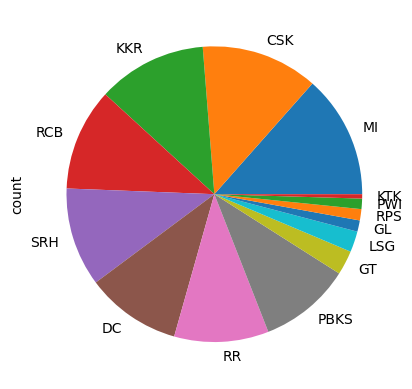

In [53]:
matches['winner'].value_counts().plot(kind='pie')

In [54]:
def missing_values(df:pd.DataFrame)->pd.DataFrame:
    missing=df.isnull().sum()
    missing_percent=(missing/len(df))*100
    missing_df=pd.DataFrame(
        {'missing_count': missing,
         'missing_percent': missing_percent,
         'action': missing_percent.apply(lambda x: 'no missing 'if x==0 else 'drop' if 0<x<=5 else " check-boundary" if 5<=x<=10 else ' imputation')}
    ).sort_values('missing_percent',ascending=False)

    print('missing values')
    print(missing_df[missing_df['missing_count']>0].to_string())
    print(f'\n columns with no missing values {(missing==0).sum()}')
    return missing_df
miss_report=missing_values(matches)

missing values
Empty DataFrame
Columns: [missing_count, missing_percent, action]
Index: []

 columns with no missing values 12


In [55]:
def parse_season(s):
    s=str(s).strip()
    if '/' in s:
        start,end=s.split('/')
        return int(start[:2] + end)
    return int(s)

matches['season']=matches['season'].apply(parse_season)

print('season value counts (sorted):')
print(matches['season'].value_counts().sort_index().to_string())
print(f' \n season: {sorted(matches.season.unique())}')


season value counts (sorted):
season
2008     56
2009     53
2010     59
2011     69
2012     74
2013     74
2014     58
2015     54
2016     56
2017     57
2018     57
2019     57
2021    115
2022     74
2023     71
2024     71
 
 season: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [56]:
matches=matches.sort_values('date').reset_index(drop=True)


<Axes: xlabel='season_year'>

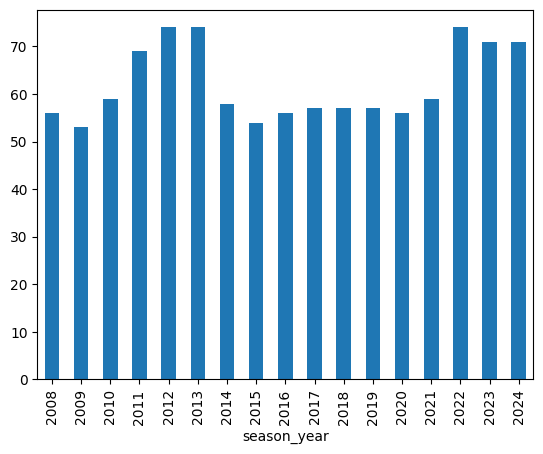

In [57]:
matches['season_year']=matches['date'].dt.year
matches['season_year'].value_counts().sort_index().plot(kind='bar')

In [58]:



def rolling_win_rate(team, before_date, df_all, window=10):
    mask = (
        ((df_all['team1'] == team) | (df_all['team2'] == team)) &
        (df_all['date'] < before_date)
    )
    past = df_all[mask].sort_values('date').tail(window)
    if len(past) == 0:
        return 0.5
    wins = (past['winner'] == team).sum()
    return round(wins / len(past), 4)

print('rolling_win_rate() defined ✓')

# Quick verify — CSK before 2023 should be > 0.5 (good team)
test_val = rolling_win_rate('CSK', pd.Timestamp('2023-01-01'), matches, window=10)
print(f'Verify CSK before 2023 (last 10): {test_val}  ← should be > 0.5')

rolling_win_rate() defined ✓
Verify CSK before 2023 (last 10): 0.4  ← should be > 0.5


In [59]:
def h2h_win_rate(team1,team2,before_date,df_all,window=20):
    mask=(
        (
            ((df_all['team1']==team1) & (df_all['team2']==team2)) | 
            ((df_all['team1']==team2) & (df_all['team2']==team1))

        )&(df_all['date']< before_date)

    )
    past=df_all[mask].tail(window)
    if len(past)==0:
        return 0.5
    wins=(past['winner']==team1).sum()
    return round(wins/len(past),4)



In [60]:
def recent_form(team,before_date,df_all,window=5):
    mask=(
        ((df_all['team1']==team) | (df_all['team2']==team)) &
        (df_all['date'] < before_date))
    
    past=df_all[mask].sort_values('date').tail(window)
    if len(past)==0:
        return 0.5
    wins=(past['winner']==team).sum()
    return round(wins/len(past),4)



In [61]:
def venue_team_win_rate(team,venue,before_date,df_all,window=10):
    mask=(
        ((df_all['team1']==team) | (df_all['team2']==team))&
        (df_all['venue']==venue)&
        (df_all['date']< before_date)

    )
    past=df_all[mask].tail(window)
    if len(past) < 3:
        return 0.5
    wins=(past['winner']==team).sum()
    return round(wins/len(past),4)


In [62]:
def venue_bat_win_rate(venue,before_date,df_all):
    mask=(
        (df_all['venue']==venue) &
        (df_all['date']< before_date) &
        (df_all['winner'].notna())
    )
    past=df_all[mask]
    if len(past)==0:
        return 0.5
    
    bat_first_wins=(
        ((past['toss_decision']=='bat') & (past['toss_winner']==past['winner'])) |
        ((past['toss_decision']=='field') & (past['toss_winner']!=past['winner']))
    ).sum()

    return round(bat_first_wins/len(past),4)



In [63]:
def venue_toss_win_rate(venue,before_date,df_all):
    mask=(
        (df_all['venue']==venue) &
        (df_all['date']< before_date)&
        (df_all['winner'].notna())
    )
    past=df_all[mask]
    if len(past)==0:
        return 0.5
    toss_winner_won=(past['toss_winner']==past['winner']).sum()
    return round(toss_winner_won/len(past),4)


In [64]:
matches['team1_win_rate']=matches.apply(lambda r: rolling_win_rate(r['team1'],r['date'],matches,window=10),axis=1)
matches['team2_win_rate']=matches.apply(lambda r: rolling_win_rate(r['team2'],r['date'],matches,window=10),axis=1)
matches['team1_recent_form']=matches.apply(lambda r: recent_form(r['team1'],r['date'],matches,window=5),axis=1)
matches['team2_recent_form']=matches.apply(lambda r: recent_form(r['team2'],r['date'],matches,window=5),axis=1)
matches['h2h_win_rate']=matches.apply(lambda r: h2h_win_rate(r['team1'],r['team2'],r['date'],matches,window=20),axis=1)
matches['venue_team1_win_rate']=matches.apply(lambda r: venue_team_win_rate(r['team1'],r['venue'],r['date'],matches,window=10),axis=1)
matches['venue_bat_first_win_rate']=matches.apply(lambda r: venue_bat_win_rate(r['venue'],r['date'],matches),axis=1)
matches['venue_toss_win_rate']=matches.apply(lambda r: venue_toss_win_rate(r['venue'],r['date'],matches),axis=1)
matches['win_rate_diff']=matches['team1_win_rate']-matches['team2_win_rate']
matches['recent_form_diff']=matches['team1_recent_form']-matches['team2_recent_form']


In [65]:

# matches['toss_winner_is_team1'] = (matches['toss_winner'] == matches['team1']).astype(int)


# def is_team1_batting_first(row):
#     toss_winner  = row['toss_winner']
#     toss_decision = row['toss_decision']
#     team1 = row['team1']
#     team2 = row['team2']

#     # Condition A: team1 won toss AND chose to bat → team1 bats first
#     if toss_winner == team1 and toss_decision == 'bat':
#         return 1
#     # Condition B: team2 won toss AND chose to field → team1 bats first
#     if toss_winner == team2 and toss_decision == 'field':
#         return 1
#     return 0

# matches['is_batting_first'] = matches.apply(is_team1_batting_first, axis=1)

# # Verify the fix — should be roughly 50% batting first
# bat_first_pct = matches['is_batting_first'].mean()
# print(f'is_batting_first mean: {bat_first_pct:.3f}  ← should be ~0.45-0.55 (was 0.0 before fix)')
# print(f'Value counts: {matches["is_batting_first"].value_counts().to_dict()}')

# # Toss winner batting first distribution
# print(f'\ntoss_winner_is_team1 mean: {matches["toss_winner_is_team1"].mean():.3f}  ← should be ~0.50')


In [122]:

matches['net_venue_win_rate']   = matches['venue_team1_win_rate'] - 0.5

In [123]:

HOME_MAP = {
    'MI'  : 'mumbai',
    'CSK' : 'chennai',
    'RCB' : 'bengaluru',
    'KKR' : 'kolkata',
    'DC'  : 'delhi',
    'SRH' : 'hyderabad',
    'RR'  : 'jaipur',
    'PBKS': 'mohali',
    'GT'  : 'ahmedabad',
    'LSG' : 'lucknow',
  
    'KTK' : '', 'GL' : '', 'RPS': '', 'PWI': ''
}

def is_home_ground(row, team_col):
    team  = row[team_col]
    venue = row['venue'].lower()
    city  = HOME_MAP.get(team, '')
    if not city:
        return 0   # defunct team → no home
    return int(city in venue)

matches['team1_is_home'] = matches.apply(lambda r: is_home_ground(r, 'team1'), axis=1)
matches['team2_is_home'] = matches.apply(lambda r: is_home_ground(r, 'team2'), axis=1)



In [125]:
matches=matches[matches['winner'].notna()].copy()
matches['y']=(matches['winner']==matches['team1']).astype(int)

print(matches['y'].value_counts().to_string())
print(f'\n class balance: {matches["y"].mean():.3f}')
print(f' total rows : {len(matches)}')

y
1    536
0    519

 class balance: 0.508
 total rows : 1055


In [126]:
train_df=matches[matches['season_year']<=2021].copy()
test_df=matches[matches['season_year']>=2022].copy()

print(f' train{train_df.shape} test {test_df.shape}')


 train(839, 29) test (216, 29)


In [127]:
drop_cols = ['winner', 'result', 'result_margin', 'target_runs',
             'id', 'date', 'toss_winner', 'season', 'y','season_year']


features= [col for col in matches.columns if col not in drop_cols]


num_cols = [
    'team1_win_rate', 'team2_win_rate',
    'team1_recent_form', 'team2_recent_form',
    'h2h_win_rate',
    'venue_team1_win_rate',
    'venue_bat_first_win_rate',
    'venue_toss_win_rate',
    'win_rate_diff','net_venue_win_rate',
    'recent_form_diff',
]

cat_cols = ['venue', 'team1', 'team2', 'toss_decision']

binary_cols = [ 'team1_is_home', 'team2_is_home']

all_features = num_cols + cat_cols + binary_cols



In [128]:
x_train = train_df[all_features]
y_train = train_df['y']
x_test  = test_df[all_features]
y_test  = test_df['y']


In [129]:
num_pipe=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

cat_pipe=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

binary_pipe=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent'))

])

preprocessor=ColumnTransformer(transformers=[
    ('num',num_pipe,num_cols),
    ('cat',cat_pipe,cat_cols),
    ('binary',binary_pipe,binary_cols)
],remainder='drop')


In [130]:
model={
    'logistic': LogisticRegression(C=0.001,max_iter=1000,solver='lbfgs',random_state=42),
    'rf': RandomForestClassifier(n_estimators=100,max_depth=4,min_samples_leaf=20,max_features='sqrt',random_state=42,n_jobs=-1),
    'xgb': XGBClassifier(n_estimators=50,max_depth=3,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,min_child_weight=20,reg_alpha=2.0,reg_lambda=3.0,eval_metric='logloss',random_state=42,n_jobs=-1),
    'lgbm': LGBMClassifier(n_estimators=100,num_leaves=8,min_child_samples=30,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,reg_alpha=2.0,reg_lambda=3.0,random_state=42,verbose=-1,n_jobs=-1),
}

In [131]:
from sklearn.model_selection import GroupKFold,cross_validate

gfk=GroupKFold(n_splits=5)
groups=train_df['season_year']

results={}

for name,model in model.items():
    pipe=Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('model',model)

    ])

    cv=cross_validate(pipe,x_train,y_train,cv=gfk.split(x_train,y_train,groups),scoring={'roc_auc':'roc_auc','accuracy':'accuracy','f1':'f1'},return_train_score=True,n_jobs=-1)
    cv_auc=cv['test_roc_auc'].mean()
    tr_auc=cv['train_roc_auc'].mean()
    gap=tr_auc -cv_auc
    cv_acc=cv['test_accuracy'].mean()
    cv_f1=cv['test_f1'].mean()

    results[name]={
        'cv_auc':cv_auc,'train_auc': tr_auc,
        'gap': gap, 'cv_acc':cv_acc,'cv_f1': cv_f1
    }

    status = 'OVERFIT' if gap > 0.10 else 'good'
    print(f'\n{name}')
    print(f'  cv_auc   : {cv_auc:.4f}')
    print(f'  train_auc: {tr_auc:.4f}')
    print(f'  gap      : {gap:.4f}  [{status}]')
    print(f'  accuracy : {cv_acc:.4f}')
    print(f'  f1       : {cv_f1:.4f}')

best_name = max(results, key=lambda k: results[k]['cv_auc'])
print(f'\n{"="*55}')
print(f'BEST MODEL: {best_name}  |  cv_auc: {results[best_name]["cv_auc"]:.4f}')




logistic
  cv_auc   : 0.5655
  train_auc: 0.5908
  gap      : 0.0253  [good]
  accuracy : 0.5207
  f1       : 0.5711

rf
  cv_auc   : 0.5632
  train_auc: 0.7005
  gap      : 0.1373  [OVERFIT]
  accuracy : 0.5480
  f1       : 0.5684

xgb
  cv_auc   : 0.5469
  train_auc: 0.6853
  gap      : 0.1384  [OVERFIT]
  accuracy : 0.5213
  f1       : 0.5366

lgbm
  cv_auc   : 0.5509
  train_auc: 0.8139
  gap      : 0.2630  [OVERFIT]
  accuracy : 0.5277
  f1       : 0.5410

BEST MODEL: logistic  |  cv_auc: 0.5655


In [139]:
from sklearn.model_selection import GridSearchCV

logistic_pipe=Pipeline(steps=[
    ('prpeocessor',preprocessor),
    ('model',LogisticRegression(random_state=42,n_jobs=-1))

])

param_grid={
    'model__C': [0.01,0.001,0.0001],
}

gs=GridSearchCV(logistic_pipe,param_grid,cv=gfk.split(x_train,y_train,groups),
                scoring='roc_auc',refit=False,n_jobs=-1)

gs.fit(x_train,y_train)



print(f'best params : {gs.best_params_}')
print(f' best cv auc : {gs.best_score_:.4f}')

cv_df=pd.DataFrame(gs.cv_results_)
print('\n all c values')

print(cv_df[['param_model__C','mean_test_score','std_test_score']].sort_values('mean_test_score',ascending=False).to_string(index=False))


best params : {'model__C': 0.01}
 best cv auc : 0.5684

 all c values
 param_model__C  mean_test_score  std_test_score
         0.0100         0.568410        0.067743
         0.0010         0.565546        0.063694
         0.0001         0.562829        0.060013


In [140]:
final_model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LogisticRegression(max_iter=1000,C=0.0100,solver='lbfgs',random_state=42,n_jobs=-1))
])

final_model.fit(x_train,y_train)
print(f' final model trained')
print(f'model: Logistic Regression (C=0.0100)')




 final model trained
model: Logistic Regression (C=0.0100)


In [141]:
y_train_pred=final_model.predict(x_train)
y_train_proba=final_model.predict_proba(x_train)[:,1]
print(f'\n train auc : {roc_auc_score(y_train,y_train_proba):.4f}')
print(f'train accuracy : {accuracy_score(y_train,y_train_pred):.4f}')



 train auc : 0.6198
train accuracy : 0.5757


In [143]:
y_pred=final_model.predict(x_test)
y_proba=final_model.predict_proba(x_test)[:,1]


test_auc=roc_auc_score(y_test,y_proba)
test_acc=accuracy_score(y_test,y_pred)
test_f1=f1_score(y_test,y_pred)

print('='*60)
print(f' final test results (2021-2024 seasons)')

print('='*60)

print(f'auc roc : {test_auc:.4f}')
print(f' accuracy: {test_acc:.4f}')
print(f' f1 score: {test_f1:.4f}')


print(f'classification report')
print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)

print(f'tn ={cm[0,0]} fp={cm[0,1]}')
print(f'fn={cm[1,0]} tp={cm[1,1]}')




 final test results (2021-2024 seasons)
auc roc : 0.4778
 accuracy: 0.4722
 f1 score: 0.4519
classification report
              precision    recall  f1-score   support

           0       0.46      0.52      0.49       105
           1       0.48      0.42      0.45       111

    accuracy                           0.47       216
   macro avg       0.47      0.47      0.47       216
weighted avg       0.47      0.47      0.47       216

tn =55 fp=50
fn=64 tp=47


In [144]:
ohe_features=(final_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_features_names_out(cat_cols).tolist())
all_feat_names=num_cols+ohe_features+binary_cols

coef=final_model.named_steps['model'].coef_[0]
feat_imp=pd.DataFrame({
    'feature': all_feat_names,
    'coef':coef,
    'abs_coef':np.abs(coef)
}).sort_values('abs_coef',ascending=False)

print('top 15 most important features')
print(feat_imp.head(15)[['feature','coefficient']].to_string(index=False))

top15=feat_imp.head(15)
color=["#8EE551" if c > 0 else '#791F1F' for c in top15['coefficient']]
plt.figure(figsize=(9,8))
plt.barh(top15['feature'][::-1],top15['coefficient'][::-1],color=colors[::-1])
plt.axvline(0,color='gray',linewidth=0.8)
plt.xlabel('coefficient')
plt.title('top 15 features ')
plt.tight_layout()
plt.show()


KeyError: 'encoder'

In [ ]:
ohe = final_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
ohe_features = ohe.get_feature_names_out(cat_cols).tolist()

all_feat_names = num_cols + ohe_features + binary_cols

coef = final_model.named_steps['model'].coef_[0]
feat_imp = pd.DataFrame({
    'feature': all_feat_names,
    'coef': coef,
    'abs_coef': np.abs(coef)
}).sort_values('abs_coef', ascending=False)

print('top 15 most important features')
print(feat_imp.head(15)[['feature', 'coef']].to_string(index=False))

top15 = feat_imp.head(15)
color = ["#8EE551" if v > 0 else "#791F1F" for v in top15['coef']]
plt.figure(figsize=(9,8))
plt.barh(top15['feature'][::-1], top15['coef'][::-1], color=color[::-1])
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel('coefficient')
plt.title('top 15 features')
plt.tight_layout()
plt.show()

AttributeError: 'LogisticRegression' object has no attribute 'feature_importances_'